In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cats = ['rec.motorcycles',  'rec.sport.baseball',   'comp.graphics',  'comp.windows.x',
'talk.politics.mideast',   'soc.religion.christian',   'sci.electronics',    'sci.med']

news_df = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'), categories=cats,random_state = 0)

count_vect = CountVectorizer(max_df = 0.95,max_features = 1000, min_df = 2,stop_words = 'english',
ngram_range=(1,2))

feat_vect = count_vect.fit_transform(news_df.data)
print('CounterVectorizer Shape:', feat_vect.shape)

CounterVectorizer Shape: (7862, 1000)


In [2]:
lda = LatentDirichletAllocation(n_components = 8, random_state = 0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

In [3]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

In [4]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print("Topic #",topic_idx)
        topic_word_indexes = topic.argsort()[::-1]
        top_indexes = topic_word_indexes[:no_top_words]
        feature_concat = ' '.join([feature_names[i] for i in top_indexes])
        print(feature_concat)
feature_names = count_vect.get_feature_names_out()
display_topics(lda, feature_names, 15)


Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import glob, os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

# 2. 구글 드라이브 내 파일 경로 설정
# MyDrive는 '/content/drive/MyDrive'로 접근합니다.
# **주의: 이 경로는 사용자의 Drive 내 실제 폴더 구조에 맞게 수정해야 합니다.**
# (예: 'MyDrive/폴더명/topics')
# 원본 코드의 경로 구조를 기반으로 가정하여 작성했습니다.
path = '/content/drive/MyDrive/topics'

# path로 지정한 디렉터리 밑에 있는 모든 .data 파일들의 파일명을 리스트로 취합
# os.path.join을 사용하여 경로와 파일 패턴을 결합합니다.
all_files = glob.glob(os.path.join(path, "*.data"))

filename_list = []
opinion_text = []

# 개별 파일들의 파일명은 filename_list 리스트로 취합,
# 개별 파일들의 파일 내용은 DataFrame 로딩 후 다시 string으로 변환하여 opinion_text 리스트로 취합
for file_ in all_files:
    # 개별 파일을 읽어서 DataFrame으로 생성
    # 원본 코드의 파라미터를 유지했습니다.
    try:
        df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    except Exception as e:
        print(f"Error reading file {file_}: {e}")
        continue

    # 절대경로로 주어진 파일명을 가공.
    # Colab/Linux 환경에서는 경로 구분자로 '/'를 사용하므로, '/'를 기준으로 분리합니다.
    # 맨 마지막 .data 확장자도 제거
    # 1. 파일명(확장자 포함) 추출
    filename_with_ext = file_.split('/')[-1]
    # 2. 확장자 제거 (가장 마지막 '.' 기준으로 분리)
    filename = filename_with_ext.split('.')[0]

    # 파일명 리스트와 파일 내용 리스트에 파일명과 파일 내용을 추가.
    filename_list.append(filename)
    opinion_text.append(df.to_string())

# 파일명 리스트와 파일 내용 리스트를 DataFrame으로 생성
document_df = pd.DataFrame({'filename': filename_list, 'opinion_text': opinion_text})

# 결과 확인
print(document_df.head())


Empty DataFrame
Columns: [filename, opinion_text]
Index: []


In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# 1. NLTK 데이터 다운로드 (최초 1회 실행)
# WordNetLemmatizer와 스톱 워드 리스트를 사용하기 위해 필요합니다.
print("NLTK 데이터 다운로드 중...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
print("NLTK 데이터 다운로드 완료.")

# WordNetLemmatizer 객체 생성
lemmar = WordNetLemmatizer()
# 영어 스톱 워드 리스트 로드
english_stopwords = stopwords.words('english')

# 2. LemNormalize() 함수 정의
def LemNormalize(text):
    """
    텍스트를 입력받아 다음을 수행하는 커스텀 토크나이저 및 정규화 함수:
    1. 단어 토큰화 (Word Tokenization)
    2. 소문자 변환
    3. 스톱 워드 제거 (Stop Word Removal)
    4. 어근 변환 (Lemmatization)
    """
    # 텍스트를 소문자로 변환하고 단어 문자로 분리 (알파벳만 남김)
    # 정규표현식을 사용하여 알파벳 문자가 아닌 것들을 공백으로 대체합니다.
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # 단어 토큰화 (띄어쓰기 기준으로 분리)
    word_list = text.lower().split()

    # 스톱 워드 제거 및 Lemmatization 적용
    # 스톱 워드가 아닌 단어에 대해서만 어근 변환을 적용합니다.
    words = [lemmar.lemmatize(word) for word in word_list if word not in english_stopwords and len(word) > 1]

    return words

# 3. 테스트용 더미 데이터프레임 생성
# 실제 'opinion_text' 칼럼에 해당한다고 가정합니다.
data = {
    'filename': ['doc1', 'doc2', 'doc3'],
    'opinion_text': [
        "The rooms were very dirty and the staff was running late. I enjoyed the stay.",
        "Excellent service! I have run the application many times. It runs fast.",
        "Running water is essential. The hotel was lacking basic amenities and was terrible."
    ]
}
document_df = pd.DataFrame(data)

print("\n--- 원본 텍스트 ---")
print(document_df[['opinion_text']])

# 4. TfidfVectorizer 객체 생성 및 LemNormalize 함수 적용
# tokenizer 인자에 LemNormalize 함수를 전달합니다.
# ngram=(1,2), min_df=0, max_df=1.0 (제한 없음을 기본값으로 설정)
tfidf_vect = TfidfVectorizer(
    tokenizer=LemNormalize,
    ngram_range=(1, 2),
    min_df=0.01, # 전체 문서의 1% 미만인 단어는 무시
    max_df=0.9 # 전체 문서의 90% 초과인 단어는 무시
)

# opinion_text 칼럼을 인자로 하여 TF-IDF 변환
ftr_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

print("\n--- TF-IDF 피처 벡터화 완료 ---")
print(f"변환된 행렬 형태: {ftr_vect.shape}")

# 5. 결과 확인 (선택 사항)
# 변환된 피처 이름(단어)들을 확인합니다.
feature_names = tfidf_vect.get_feature_names_out()
print("\n--- 추출된 피처 (단어) 예시 ---")
print(feature_names[:20])

NLTK 데이터 다운로드 중...
NLTK 데이터 다운로드 완료.

--- 원본 텍스트 ---
                                                                          opinion_text
0        The rooms were very dirty and the staff was running late. I enjoyed the stay.
1              Excellent service! I have run the application many times. It runs fast.
2  Running water is essential. The hotel was lacking basic amenities and was terrible.

--- TF-IDF 피처 벡터화 완료 ---
변환된 행렬 형태: (3, 41)

--- 추출된 피처 (단어) 예시 ---
['amenity' 'amenity terrible' 'application' 'application many' 'basic'
 'basic amenity' 'dirty' 'dirty staff' 'enjoyed' 'enjoyed stay'
 'essential' 'essential hotel' 'excellent' 'excellent service' 'fast'
 'hotel' 'hotel lacking' 'lacking' 'lacking basic' 'late']


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# NLTK 데이터 다운로드 (LemNormalize 함수에 필요)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True) # Add this line to download punkt_tab

lemmar = WordNetLemmatizer()
english_stopwords = stopwords.words('english')

def LemNormalize(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    word_list = text.lower().split()
    words = [lemmar.lemmatize(word) for word in word_list if word not in english_stopwords and len(word) > 1]
    return words

# Recreate dummy document_df for consistency with clustering steps
data = {
    'filename': ['doc1', 'doc2', 'doc3'],
    'opinion_text': [
        "The rooms were very dirty and the staff was running late. I enjoyed the stay.",
        "Excellent service! I have run the application many times. It runs fast.",
        "Running water is essential. The hotel was lacking basic amenities and was terrible."
    ]
}
document_df = pd.DataFrame(data)

tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english' , ngram_range=(1,2), min_df= 0.01, max_df= 0.9 ) # Adjust min_df/max_df if needed to get features from 3 docs

feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
# 5개 집합으로 군집화 수행. 예제를 위해 동일한 클러스터링 결과 도출용 random_state게
km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_

In [10]:
document_df['cluster_label'] = cluster_label
document_df.head()


,filename,opinion_text,cluster_label
0,doc1,The rooms were very dirty and the staff was running late. I enjoyed the stay.,2
1,doc2,Excellent service! I have run the application many times. It runs fast.,0
2,doc3,Running water is essential. The hotel was lacking basic amenities and was terrible.,1


In [11]:
document_df [document_df ['cluster_label' ]==0] .sort_values(by='filename')

,filename,opinion_text,cluster_label
1,doc2,Excellent service! I have run the application many times. It runs fast.,0


In [12]:
document_df [document_df [ 'cluster_label' ]==1 ] .sort_values(by='filename')

,filename,opinion_text,cluster_label
2,doc3,Running water is essential. The hotel was lacking basic amenities and was terrible.,1


In [13]:
document_df [document_df['cluster_label' ]==2].sort_values (by='filename')

,filename,opinion_text,cluster_label
0,doc1,The rooms were very dirty and the staff was running late. I enjoyed the stay.,2


In [14]:
document_df [document_df [ 'cluster_label' ]==3]. sort_values(by= 'filename')

,filename,opinion_text,cluster_label


In [15]:
document_df [document_df[ 'cluster_label' ]==4].sort_values(by='filename')

,filename,opinion_text,cluster_label


In [16]:
from sklearn.cluster import KMeans
# 3개의 집합으로 군집화
km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_

# 소속 클러스터를 cl니ster_label 칼럼으로 할당하고 cluster_label 값으로 정렬
document_df ['cluster_label'] = cluster_label
document_df.sort_values(by='cluster_label')


,filename,opinion_text,cluster_label
1,doc2,Excellent service! I have run the application many times. It runs fast.,0
2,doc3,Running water is essential. The hotel was lacking basic amenities and was terrible.,1
0,doc1,The rooms were very dirty and the staff was running late. I enjoyed the stay.,2


In [17]:
cluster_centers = km_cluster.cluster_centers_
print('cluster_centers shape :', cluster_centers.shape)
print(cluster_centers)


cluster_centers shape : (3, 39)
[[0.         0.         0.25819889 0.25819889 0.         0.
  0.         0.         0.         0.         0.         0.
  0.25819889 0.25819889 0.25819889 0.         0.         0.
  0.         0.         0.         0.         0.         0.51639778
  0.25819889 0.25819889 0.         0.         0.         0.25819889
  0.25819889 0.         0.         0.         0.         0.25819889
  0.25819889 0.         0.        ]
 [0.26190578 0.26190578 0.         0.         0.26190578 0.26190578
  0.         0.         0.         0.         0.26190578 0.26190578
  0.         0.         0.         0.26190578 0.26190578 0.26190578
  0.26190578 0.         0.         0.         0.         0.
  0.         0.         0.19918609 0.         0.26190578 0.
  0.         0.         0.         0.         0.26190578 0.
  0.         0.26190578 0.26190578]
 [0.         0.         0.         0.         0.         0.
  0.28195987 0.28195987 0.28195987 0.28195987 0.         0.
  0.    

In [18]:
def get_cluster_details(cluster_model, cluster_data, feature_names, clusters_num,top_n_features=10):
  cluster_details = {}
  centroid_feature_ordered_ind = cluster_model.cluster_centers_.argsort()[:, ::-1]
  for cluster_num in range(clusters_num):
    cluster_details[cluster_num] = {}
    cluster_details[cluster_num]['cluster'] = cluster_num

    top_feature_indexes = centroid_feature_ordered_ind[cluster_num, :top_n_features]
    top_features = [feature_names[ind] for ind in top_feature_indexes]

    top_feature_values = cluster_model.cluster_centers_[cluster_num, top_feature_indexes].tolist()
    cluster_details[cluster_num]['top_features'] = top_features
    cluster_details[cluster_num]['top_features_value'] = top_feature_values
    # Corrected filtering logic
    filenames = cluster_data[cluster_data['cluster_label'] == cluster_num]['filename']
    filenames = filenames.values.tolist()
    cluster_details[cluster_num]['filenames'] = filenames

  return cluster_details

In [19]:
def print_cluster_details(cluster_details):
  for cluster_num, cluster_detail in cluster_details.items():
    print('####### Cluster {0}'.format(cluster_num))
    print('Top features:', cluster_detail['top_features'])
    print('Review 파일명 :',cluster_detail['filenames'][:7])
    print('==================================================')

In [20]:
feature_names = tfidf_vect.get_feature_names_out()
cluster_details = get_cluster_details(cluster_model = km_cluster,cluster_data = document_df,feature_names =feature_names,clusters_num = 3, top_n_features = 10)
print_cluster_details(cluster_details)

####### Cluster 0
Top features: ['run', 'time', 'time run', 'service', 'run fast', 'service run', 'run application', 'application', 'application time', 'excellent service']
Review 파일명 : ['doc2']
####### Cluster 1
Top features: ['water essential', 'water', 'terrible', 'lacking', 'hotel lacking', 'lacking basic', 'running water', 'amenity terrible', 'basic amenity', 'amenity']
Review 파일명 : ['doc3']
####### Cluster 2
Top features: ['staff running', 'stay', 'late', 'room dirty', 'room', 'running late', 'staff', 'dirty staff', 'dirty', 'enjoyed']
Review 파일명 : ['doc1']


8장

In [21]:
import numpy as np
def cos_similarity(v1, v2):
  dot_product = np.dot(v1,v2)
  l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
  similarity = dot_product / l2_norm

  return similarity

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = ['if you take the blue pill, the story ends',
'if you take the red pill, you stay in Wonderland',
'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)


(3, 18)


In [23]:
feature_vect_dense = feature_vect_simple.todense()
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect2 )
print('문장 1, 문장 2 Cosine 유사도: {0: .3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도:  0.402


In [24]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect3 )
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))

vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect2, vect3 )
print('문장 2, 문장 3 Cosine 유사도: {0: .3f}'.format(similarity_simple))




문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도:  0.456


In [25]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [26]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0],feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [27]:
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)


[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


In [29]:
# 오류가 발생하기 직전의 코드 위치에 삽입
print("--- 현재 DataFrame 정보 확인 ---")

# 1. DataFrame 변수 이름 확인 (예: document_df)
# 만약 코드가 document_df를 사용하지 않는다면 해당 변수 이름으로 변경하세요.
if 'document_df' in locals() or 'document_df' in globals():
    print("DataFrame 컬럼 목록:", document_df.columns.tolist())
    print("DataFrame 상위 5행:\n", document_df.head())
else:
    print("DataFrame 변수 (document_df)가 정의되지 않았거나 범위를 벗어났습니다.")

--- 현재 DataFrame 정보 확인 ---
DataFrame 컬럼 목록: ['filename', 'opinion.text']
DataFrame 상위 5행:
 Empty DataFrame
Columns: [filename, opinion.text]
Index: []


In [33]:
import pandas as pd
import glob, os
import warnings
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 1. NLTK 필수 데이터 다운로드 (Colab에서 매번 필요)
# ---------------------------------------------------------
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True) # 최신 버전 호환용

from nltk.stem import WordNetLemmatizer

# ---------------------------------------------------------
# 2. 구글 드라이브 마운트
# ---------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

# ---------------------------------------------------------
# 3. 경로 설정 (★★★ 사용자 수정 필수 ★★★)
# ---------------------------------------------------------
# 본인의 구글 드라이브 내 'topics' 폴더가 있는 정확한 경로를 입력하세요.
# 예: '/content/drive/MyDrive/Colab Notebooks/OpinosisDataset1.0/topics'
path = '/content/drive/MyDrive/OpinosisDataset1.0/topics'

# 경로가 실제로 존재하는지 확인하는 안전장치
if not os.path.exists(path):
    print(f"오류: 경로를 찾을 수 없습니다. -> {path}")
    print("path 변수의 경로를 다시 확인해 주세요.")
else:
    print(f"경로 확인 완료: {path}")

# ---------------------------------------------------------
# 4. 파일 읽기 및 데이터프레임 생성
# ---------------------------------------------------------
# os.path.join을 사용하여 경로 결합 (*.data 파일 찾기)
all_files = glob.glob(os.path.join(path, "*.data"))

filename_list = []
opinion_text = []

if len(all_files) == 0:
    print("주의: 해당 경로에서 .data 파일을 하나도 찾지 못했습니다!")
else:
    print(f"총 {len(all_files)}개의 파일을 발견했습니다. 데이터 로드를 시작합니다...")

    for file_ in all_files:
        # (1) 파일 읽기
        try:
            # header=0으로 읽으면 첫 줄이 컬럼이 되므로, to_string()으로 전체를 문자로 합칩니다.
            df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')

            # 절대 경로로 주어진 파일명을 가공 (리눅스 경로 '/' 기준 분리)
            filename_ = file_.split('/')[-1]
            filename = filename_.split('.')[0]

            # 리스트에 저장
            filename_list.append(filename)
            opinion_text.append(df.to_string())

        except Exception as e:
            print(f"파일 읽기 에러 ({file_}): {e}")

    # (2) DataFrame 생성 (컬럼 이름을 명확하게 지정)
    document_df = pd.DataFrame({
        'filename': filename_list,
        'opinion_text': opinion_text
    })

    # 결과 확인
    print("\n--- 데이터프레임 생성 완료 ---")
    print(document_df.head())


# ---------------------------------------------------------
# 5. LemNormalize 함수 정의 및 TF-IDF 수행
# ---------------------------------------------------------

# Lemmatization을 위한 함수 정의
lemmar = WordNetLemmatizer()

def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

def LemNormalize(text):
    # 소문자 변환 후 구두점 제거 딕셔너리 생성
    remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
    return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))

# 데이터가 있을 때만 실행
if len(document_df) > 0:
    # TF-IDF 벡터화
    tfidf_vect = TfidfVectorizer(
        tokenizer=LemNormalize,
        ngram_range=(1, 2),
        min_df=0.05,
        max_df=0.85
    )

    # DataFrame의 'opinion_text' 컬럼을 이용하여 피처 벡터화
    feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

    print("\n--- TF-IDF 처리 완료 ---")
    print(f"Shape: {feature_vect.shape}")

    # ---------------------------------------------------------
    # 6. K-Means 군집화 (예시: 5개 군집)
    # ---------------------------------------------------------
    km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0)
    km_cluster.fit(feature_vect)

    cluster_label = km_cluster.labels_
    cluster_centers = km_cluster.cluster_centers_

    document_df['cluster_label'] = cluster_label
    print("\n--- 군집화 완료 ---")
    print(document_df.head())

else:
    print("\n데이터가 로드되지 않아 TF-IDF를 수행할 수 없습니다.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
경로 확인 완료: /content/drive/MyDrive/OpinosisDataset1.0/topics
총 51개의 파일을 발견했습니다. 데이터 로드를 시작합니다...

--- 데이터프레임 생성 완료 ---
                         filename  \
0  satellite_garmin_nuvi_255W_gps   
1    updates_garmin_nuvi_255W_gps   
2        price_holiday_inn_london   
3         staff_swissotel_chicago   
4      interior_honda_accord_2008   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [34]:
from sklearn.metrics.pairwise import cosine_similarity
hotel_indexes = document_df[document_df['cluster_label']==2] .index
print('호텔로 클러스터링 된 문서들의 DataFrame Index： ',hotel_indexes)
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명',comparison_docname,' 와 타 문서 유사도######')

''' document_df에서 추출한 Index 객체를 feature_vect로 입력해 호텔 군집화된 feature_vect 추출
이를 이용해 호텔로 군집화된 문서 중 첫 번째 문서와 다른 문서 간의 코사인 유사도 측정.'''
similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)


호텔로 클러스터링 된 문서들의 DataFrame Index：  Index([0, 12, 19, 23, 25, 30, 32, 33, 39, 42, 43, 48], dtype='int64')
##### 비교 기준 문서명 satellite_garmin_nuvi_255W_gps  와 타 문서 유사도######
[[1.         0.07536333 0.07219602 0.02550625 0.05163268 0.06895823
  0.02094988 0.03230615 0.05216628 0.02744098 0.1274041  0.10915952]]


가장 유사도가 큰 파일명 및 유사도:
 filename      directions_garmin_nuvi_255W_gps
similarity                           0.127404
Name: 43, dtype: object


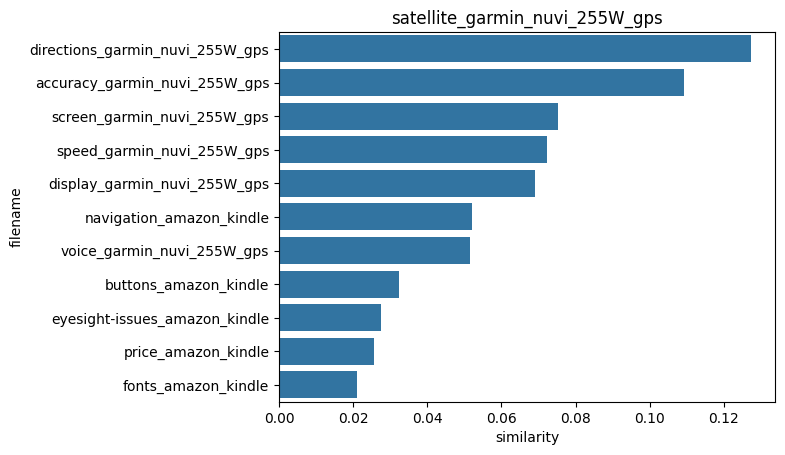

In [35]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sorted_index = similarity_pair.argsort()[:,::-1 ]
sorted_index = sorted_index[:, 1 :]
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1 ]
hotel_1_sim_value = hotel_1_sim_value[1:]

hotel_1_sim_df = pd.DataFrame()

# Check if there are any similar documents left after removing self-similarity
if len(hotel_sorted_indexes) > 0:
    hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
    hotel_1_sim_df['similarity' ] = hotel_1_sim_value
    print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0, :])
    sns.barplot(x='similarity', y='filename',data=hotel_1_sim_df)
    plt.title(comparison_docname)
else:
    print(f"클러스터 {comparison_docname}에는 비교할 다른 유사 문서가 없습니다.")

9장.

In [36]:
# OpenJDK 11 설치
!sudo apt-get install openjdk-11-jdk-headless -qq > /dev/null

# 환경 변수 설정
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/openjdk-11'
!java -version

openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)


In [37]:
# JPype1 설치 (KoNLPy가 자바 모듈을 파이썬에서 사용할 수 있도록 연결해 줌)
!pip install JPype1 -qq

# KoNLPy 설치
!pip install konlpy -qq

In [38]:

import pandas as pd
train_df = pd.read_csv('ratings_train.txt',sep='\t',encoding = 'utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [39]:
train_df['label'].value_counts( )

,count
label,
0,75173
1,74827


In [40]:
import re
train_df = train_df.fillna(' ')

train_df['docuemnt'] = train_df['document'].apply(lambda x: re.sub(r"\d+", " ", x))

test_df = pd.read_csv('ratings_test.txt',sep = '\t',encoding = 'utf-8')
test_df = test_df.fillna(' ')
test_df['docuemnt']= test_df['document'].apply(lambda x: re.sub(r"\d+", " ", x))

train_df.drop('id',axis =1,inplace = True)
test_df.drop('id',axis=1,inplace = True)

In [41]:
from konlpy.tag import Twitter
twitter = Twitter()
def tw_tokenizer(text):
# 입력 인자로 들어온 텍스트를 형태소 단어로 토큰화해 리스트 형태로 반환
  tokens_ko = twitter.morphs(text)
  return tokens_ko

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1, 2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])



In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from konlpy.tag import Twitter

# Initialize Twitter tokenizer and define tw_tokenizer (copied from cell 5OvyxfgzhM6d)
twitter = Twitter()
def tw_tokenizer(text):
  tokens_ko = twitter.morphs(text)
  return tokens_ko

# Create TfidfVectorizer and transform data (copied from cell 5OvyxfgzhM6d)
tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1, 2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document']) # Assumes train_df is defined from previous cells
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

# Original code for GridSearchCV
lg_clf = LogisticRegression(random_state=0, solver='liblinear')
params = { 'C': [1, 3.5, 4.5, 5.5, 10] }
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])
print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8629


In [44]:
from sklearn.metrics import accuracy_score
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])
best_estimator = grid_cv.best_estimator_
preds = best_estimator.predict(tfidf_matrix_test)
print('Logistic Regression 정확도: ',accuracy_score(test_df['label'], preds))


Logistic Regression 정확도:  0.86534
